# 04. ML 베이스라인 (ML Baseline)
## 서울 성동구 요식 가맹점 조기 경보 시스템 | 빅콘테스트 2025

> **STEP 11**: 분류 모델 성능 평가 — 5-fold StratifiedKFold, AUC-ROC, Lift@k


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

snap = pd.read_csv('../p_project_snapshot.csv', encoding='utf-8-sig')

# 18개 피처 그룹 정의 (내부 10 + 경쟁 6 + 외부 2) — README 7.2절과 동일
FEAT_INTERNAL    = ['f_sales_lvl', 'f_trx_lvl', 'f_spend_lvl',
                    'f_sales_trend', 'f_trx_trend',
                    'f_return_rate', 'f_return_trend',
                    'f_float_ratio', 'f_float_trend', 'f_resid_ratio']
FEAT_COMPETITIVE = ['f_rank_ind', 'f_rank_dist',
                    'f_rank_ind_trend', 'f_rank_dist_trend',
                    'f_vs_ind_sales', 'f_vs_ind_trend']
FEAT_EXTERNAL    = ['f_peer_close_ind', 'f_peer_close_dist']
FEAT_ALL = FEAT_INTERNAL + FEAT_COMPETITIVE + FEAT_EXTERNAL

print(f'snap shape: {snap.shape}')
print(f'FEAT_ALL: {len(FEAT_ALL)} features  (내부 {len(FEAT_INTERNAL)} + 경쟁 {len(FEAT_COMPETITIVE)} + 외부 {len(FEAT_EXTERNAL)})')

snap shape: (4183, 53)
FEAT_ALL: 18 features  (내부 10 + 경쟁 6 + 외부 2)


### 11-1. 데이터 준비 & 평가 함수

In [2]:
# ================================================================
# STEP 1: 데이터 준비 & 평가 함수
# ================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline

X_cols = ['dw_' + f for f in FEAT_ALL]
X = snap[X_cols].fillna(snap[X_cols].median())
y = snap['is_closed_obs'].values
print(f'피처: {len(X_cols)}개, 점포: {len(X)}, 폐업: {y.sum()} / 생존: {(y==0).sum()}')
print(f'기저율(base rate): {y.mean()*100:.2f}%')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def eval_proba(y_true, proba, name):
    auc  = roc_auc_score(y_true, proba)
    ap   = average_precision_score(y_true, proba)
    n    = len(y_true)
    base = y_true.mean()
    for k_pct in [0.10, 0.05]:
        k    = max(1, int(n*k_pct))
        topk = np.argsort(proba)[-k:]
        prec = y_true[topk].mean()
        lift = prec / base
        print(f'  {name:<16} AUC={auc:.3f}  AP={ap:.3f}  P@{int(k_pct*100)}%={prec*100:.1f}%  Lift@{int(k_pct*100)}%={lift:.1f}x')
    return auc

피처: 18개, 점포: 4183, 폐업: 30 / 생존: 4153
기저율(base rate): 0.72%


### 11-2. Logistic Regression

In [3]:
# LogReg
pipe_lr = Pipeline([('sc', StandardScaler()),
                    ('clf', LogisticRegression(class_weight='balanced', C=0.1, max_iter=500))])
lr_prob = cross_val_predict(pipe_lr, X, y, cv=cv, method='predict_proba')[:,1]
eval_proba(y, lr_prob, 'LogisticReg')

  LogisticReg      AUC=0.605  AP=0.013  P@10%=1.9%  Lift@10%=2.7x
  LogisticReg      AUC=0.605  AP=0.013  P@5%=2.4%  Lift@5%=3.3x


0.6045107954089414

### 11-3. Random Forest (기본)

In [4]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced',
                            min_samples_leaf=5, random_state=42)
rf_prob = cross_val_predict(rf, X.values, y, cv=cv, method='predict_proba')[:,1]
eval_proba(y, rf_prob, 'RandomForest')

  RandomForest     AUC=0.735  AP=0.033  P@10%=2.9%  Lift@10%=4.0x
  RandomForest     AUC=0.735  AP=0.033  P@5%=3.8%  Lift@5%=5.3x


0.7351472830885304

### 11-4. EWS 점수 비교 & RF 피처 중요도

In [5]:
# EWS 기본 점수 vs ML 비교
ews_score = snap['risk_score'].fillna(50).values
eval_proba(y, ews_score/100, 'EWS rank-score')

# RF 기본 피처 중요도 (참고용)
rf_full = RandomForestClassifier(n_estimators=300, max_depth=5, class_weight='balanced',
                                  min_samples_leaf=5, random_state=42)
rf_full.fit(X.values, y)
fi = pd.Series(rf_full.feature_importances_,
               index=[c[3:] for c in X.columns]).sort_values(ascending=False)
print('RF 피처 중요도 Top 10:')
for feat, imp in fi.head(10).items():
    bar = '#' * int(imp*300)
    print(f'  {feat:<30} {imp:.4f} {bar}')

  EWS rank-score   AUC=0.668  AP=0.018  P@10%=1.7%  Lift@10%=2.3x
  EWS rank-score   AUC=0.668  AP=0.018  P@5%=1.9%  Lift@5%=2.7x
RF 피처 중요도 Top 10:
  f_trx_trend                    0.1274 ######################################
  f_sales_trend                  0.1146 ##################################
  f_vs_ind_trend                 0.0956 ############################
  f_rank_dist_trend              0.0736 ######################
  f_trx_lvl                      0.0632 ##################
  f_resid_ratio                  0.0610 ##################
  f_rank_ind_trend               0.0520 ###############
  f_peer_close_dist              0.0493 ##############
  f_vs_ind_sales                 0.0454 #############
  f_float_ratio                  0.0446 #############


In [6]:
# ================================================================
# STEP 11b: RF 하이퍼파라미터 튜닝 (RandomizedSearchCV)
# ================================================================
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 7, None],
    'min_samples_leaf': [2, 3, 5, 8, 10],
    'max_features':     ['sqrt', 'log2', 0.5, 0.7],
    'min_samples_split':[2, 5, 10],
}
rf_base_tune = RandomForestClassifier(class_weight='balanced', random_state=42)
rscv = RandomizedSearchCV(
    rf_base_tune, param_dist,
    n_iter=40, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1, refit=True, verbose=0
)
rscv.fit(X.values, y)

print('제일 좋은 파라미터:', rscv.best_params_)
print(f'최적 CV AUC: {rscv.best_score_:.4f}')
print()

rf_tuned_prob = cross_val_predict(rscv.best_estimator_, X.values, y, cv=cv, method='predict_proba')[:,1]
eval_proba(y, rf_tuned_prob, 'RF (튜닝)')
print()
base_auc  = roc_auc_score(y, rf_prob)
tuned_auc = roc_auc_score(y, rf_tuned_prob)
print(f'RF 기본  AUC: {base_auc:.4f}')
print(f'RF 튜닝  AUC: {tuned_auc:.4f}  (+{tuned_auc - base_auc:.4f})')

snap['rf_risk_prob'] = rf_tuned_prob
snap.to_csv('../p_project_snapshot.csv', index=False, encoding='utf-8-sig')
print('[SAVED] p_project_snapshot.csv  (튜닝 RF 확률 저장)')

제일 좋은 파라미터: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': None}
최적 CV AUC: 0.7711

  RF (튜닝)          AUC=0.764  AP=0.034  P@10%=3.1%  Lift@10%=4.3x
  RF (튜닝)          AUC=0.764  AP=0.034  P@5%=4.8%  Lift@5%=6.7x

RF 기본  AUC: 0.7351
RF 튜닝  AUC: 0.7641  (+0.0290)
[SAVED] p_project_snapshot.csv  (튜닝 RF 확률 저장)


---
## STEP 4. 베이스라인 성능 시각화 (ml_01 ~ ml_04)

> LR / RF / EWS 5개 모델의 ROC·PR 곡선, 피처 중요도, Cumulative Gain, 점수 분포를 확인합니다.  
> 부스팅 모델(XGB/LGB/CB) 추가 전 베이스라인 비교 구간입니다.

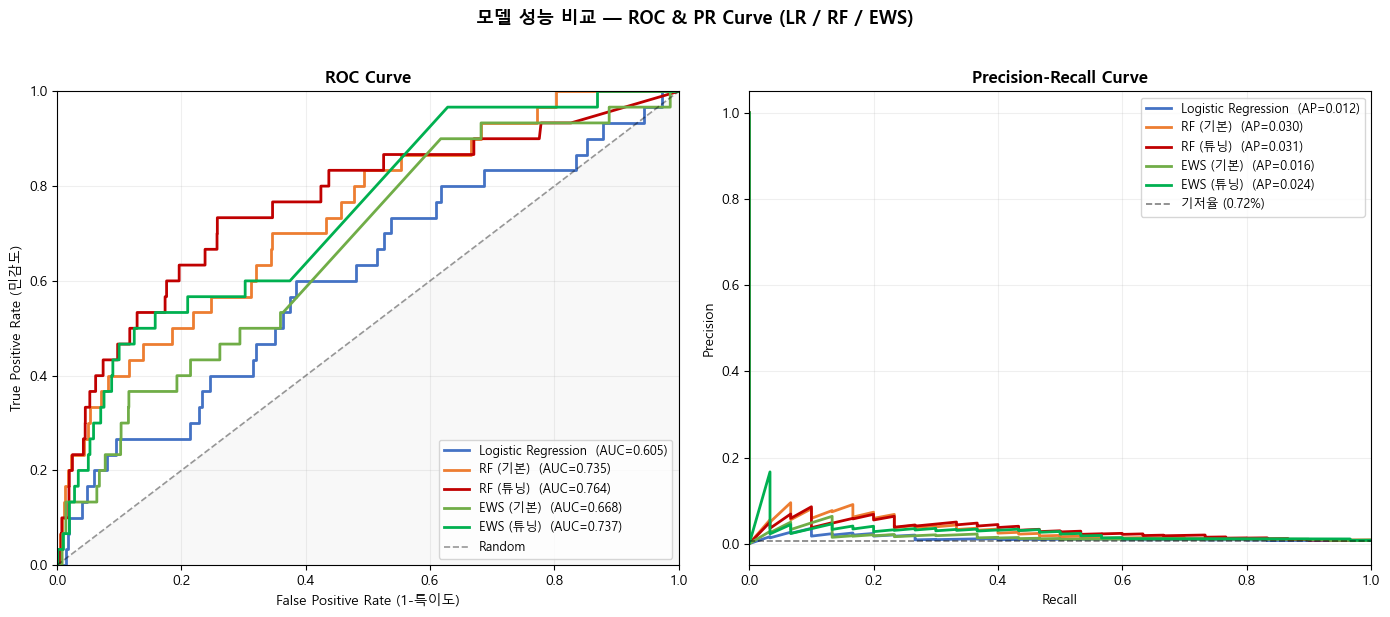

saved: ml_01_roc_pr_curves.png


In [7]:
# ================================================================
# 시각화 1: ROC Curve & Precision-Recall Curve
# ================================================================
import matplotlib
import matplotlib.pyplot as plt
import os
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
from sklearn.metrics import roc_curve, precision_recall_curve, auc as sk_auc

OUT_DIR = '../outputs/'
os.makedirs(OUT_DIR, exist_ok=True)

# EWS 튜닝 결과 로드 (05_ews_tuning 실행 후 생성)
if os.path.exists('../p_project_snapshot_tuned.csv'):
    snap_t = pd.read_csv('../p_project_snapshot_tuned.csv', encoding='utf-8-sig')
    ews_tuned_prob = snap_t['risk_score_opt'].fillna(50).values / 100
else:
    ews_tuned_prob = ews_score / 100   # fallback: 기본 EWS 사용

MODELS = {
    'Logistic Regression': lr_prob,
    'RF (기본)':           rf_prob,
    'RF (튜닝)':           rf_tuned_prob,
    'EWS (기본)':          ews_score / 100,
    'EWS (튜닝)':          ews_tuned_prob,
}
COLORS = ['#4472C4', '#ED7D31', '#C00000', '#70AD47', '#00B050']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for (name, proba), color in zip(MODELS.items(), COLORS):
    fpr, tpr, _ = roc_curve(y, proba)
    val = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={val:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1.2, alpha=0.4, label='Random')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate (1-특이도)'); ax.set_ylabel('True Positive Rate (민감도)')
ax.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(True, alpha=0.2)
ax.set_xlim(0,1); ax.set_ylim(0,1)

ax = axes[1]
for (name, proba), color in zip(MODELS.items(), COLORS):
    prec, rec, _ = precision_recall_curve(y, proba)
    val = sk_auc(rec, prec)
    ax.plot(rec, prec, color=color, lw=2, label=f'{name}  (AP={val:.3f})')
ax.axhline(y.mean(), color='k', linestyle='--', lw=1.2, alpha=0.5,
           label=f'기저율 ({y.mean()*100:.2f}%)')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.2)
ax.set_xlim(0,1)

plt.suptitle('모델 성능 비교 — ROC & PR Curve (LR / RF / EWS)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_01_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_01_roc_pr_curves.png')

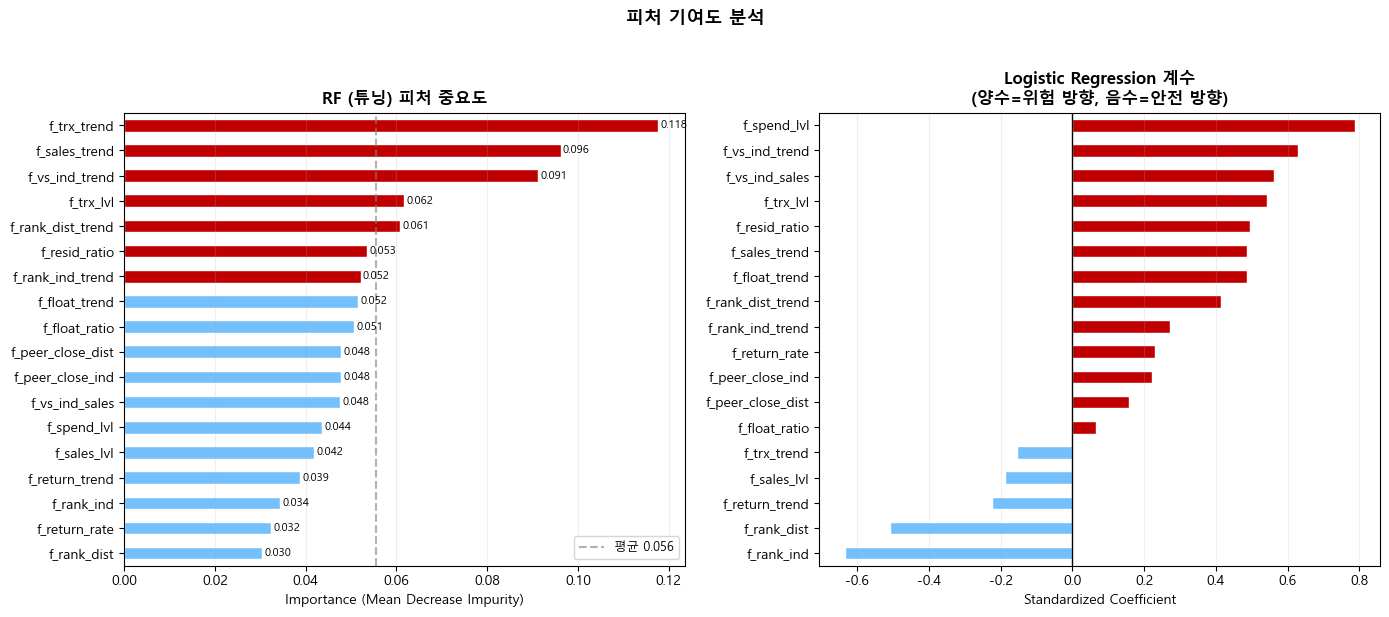

saved: ml_02_feature_importance.png


In [8]:
# ================================================================
# 시각화 2: 피처 중요도 (RF 튜닝 vs LR 계수)
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
feat_labels_v = [c[3:] for c in X.columns]   # dw_f_X → f_X

ax = axes[0]
fi = pd.Series(rscv.best_estimator_.feature_importances_, index=feat_labels_v).sort_values()
bar_colors = ['#C00000' if v >= fi.quantile(0.6) else '#74C0FC' for v in fi]
fi.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(fi.mean(), color='gray', linestyle='--', alpha=0.6, label=f'평균 {fi.mean():.3f}')
ax.set_title('RF (튜닝) 피처 중요도', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance (Mean Decrease Impurity)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2, axis='x')
for i, v in enumerate(fi.values):
    ax.text(v + 0.0005, i, f'{v:.3f}', va='center', fontsize=8)

ax = axes[1]
pipe_lr_fi = Pipeline([('sc', StandardScaler()),
                        ('clf', LogisticRegression(class_weight='balanced', C=0.1, max_iter=500))])
pipe_lr_fi.fit(X, y)
lr_coef = pd.Series(pipe_lr_fi.named_steps['clf'].coef_[0], index=feat_labels_v).sort_values()
bar_colors_lr = ['#C00000' if v > 0 else '#74C0FC' for v in lr_coef]
lr_coef.plot(kind='barh', ax=ax, color=bar_colors_lr, edgecolor='white')
ax.axvline(0, color='black', lw=1.0)
title_lr = 'Logistic Regression 계수' + chr(10) + '(양수=위험 방향, 음수=안전 방향)'
ax.set_title(title_lr, fontsize=12, fontweight='bold')
ax.set_xlabel('Standardized Coefficient')
ax.grid(True, alpha=0.2, axis='x')

plt.suptitle('피처 기여도 분석', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_02_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_02_feature_importance.png')

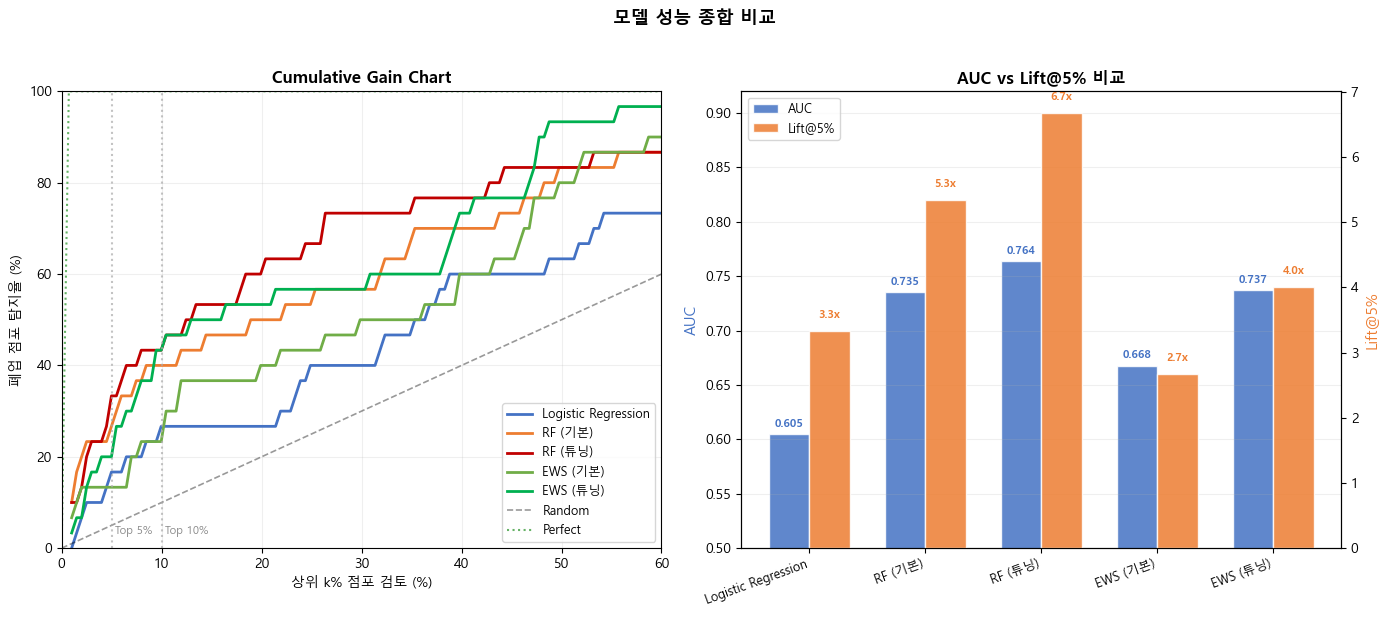

saved: ml_03_model_comparison.png


In [9]:
# ================================================================
# 시각화 3: Cumulative Gain & 모델 성능 비교 바 차트
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
n_total = len(y)
total_pos = y.sum()
pct_range = np.linspace(0.01, 1.0, 200)

ax = axes[0]
for (name, proba), color in zip(MODELS.items(), COLORS):
    gains = []
    for pct in pct_range:
        k = max(1, int(n_total * pct))
        topk = np.argsort(proba)[-k:]
        gains.append(y[topk].sum() / total_pos)
    ax.plot(pct_range * 100, np.array(gains) * 100, color=color, lw=2, label=name)
ax.plot([0,100],[0,100],'k--', lw=1.2, alpha=0.4, label='Random')
ax.plot([0, total_pos/n_total*100, 100],[0,100,100],'g:', lw=1.5, alpha=0.6, label='Perfect')
ax.axvline(5,  color='#AAAAAA', linestyle=':', alpha=0.7)
ax.axvline(10, color='#AAAAAA', linestyle=':', alpha=0.7)
ax.text(5.3, 3, 'Top 5%', fontsize=8, color='#888888')
ax.text(10.3, 3, 'Top 10%', fontsize=8, color='#888888')
ax.set_xlabel('상위 k% 점포 검토 (%)'); ax.set_ylabel('폐업 점포 탐지율 (%)')
ax.set_title('Cumulative Gain Chart', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(True, alpha=0.2)
ax.set_xlim(0, 60); ax.set_ylim(0, 100)

ax = axes[1]
model_names_v = list(MODELS.keys())
aucs_all   = [roc_auc_score(y, p) for p in MODELS.values()]
lifts5_all = []
for proba in MODELS.values():
    k = max(1, int(n_total * 0.05))
    topk = np.argsort(proba)[-k:]
    lifts5_all.append(y[topk].mean() / y.mean())

x_pos = np.arange(len(model_names_v))
w = 0.35
bars1 = ax.bar(x_pos - w/2, aucs_all, w, label='AUC', color='#4472C4', alpha=0.85, edgecolor='white')
ax_twin = ax.twinx()
bars2 = ax_twin.bar(x_pos + w/2, lifts5_all, w, label='Lift@5%', color='#ED7D31', alpha=0.85, edgecolor='white')
ax.set_ylabel('AUC', color='#4472C4', fontsize=11)
ax_twin.set_ylabel('Lift@5%', color='#ED7D31', fontsize=11)
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names_v, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0.5, 0.92); ax.set_title('AUC vs Lift@5% 비교', fontsize=12, fontweight='bold')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8,
            color='#4472C4', fontweight='bold')
for bar in bars2:
    ax_twin.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.15,
                f'{bar.get_height():.1f}x', ha='center', va='bottom', fontsize=8,
                color='#ED7D31', fontweight='bold')

lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, loc='upper left', fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('모델 성능 종합 비교', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_03_model_comparison.png')

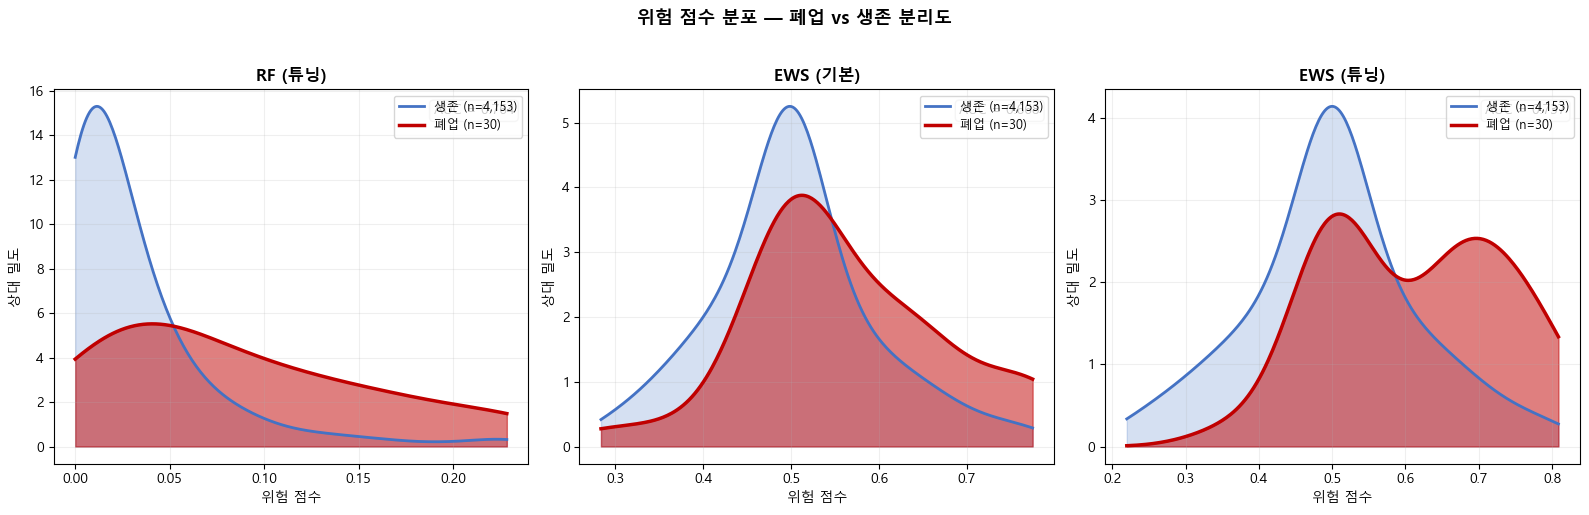

saved: ml_04_score_distribution.png


In [10]:
# ================================================================
# 시각화 4: 위험 점수 분포 — 폐업 vs 생존 분리도
# ================================================================
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_items = [
    ('RF (튜닝)',   rf_tuned_prob,  axes[0]),
    ('EWS (기본)', ews_score/100,   axes[1]),
    ('EWS (튜닝)', ews_tuned_prob,  axes[2]),
]

for name, proba, ax in plot_items:
    c_vals = proba[y == 1]
    a_vals = proba[y == 0]
    lo = np.percentile(proba, 1); hi = np.percentile(proba, 99)
    xs = np.linspace(lo, hi, 300)

    if len(a_vals) > 3:
        kde_a = gaussian_kde(np.clip(a_vals, lo, hi), bw_method=0.4)
        ax.fill_between(xs, kde_a(xs), alpha=0.22, color='#4472C4')
        ax.plot(xs, kde_a(xs), color='#4472C4', lw=2, label=f'생존 (n={len(a_vals):,})')

    if len(c_vals) > 2:
        kde_c = gaussian_kde(np.clip(c_vals, lo, hi), bw_method=0.5)
        ax.fill_between(xs, kde_c(xs), alpha=0.5, color='#C00000')
        ax.plot(xs, kde_c(xs), color='#C00000', lw=2.5, label=f'폐업 (n={len(c_vals)})')

    auc_val = roc_auc_score(y, proba)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('위험 점수'); ax.set_ylabel('상대 밀도')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
    ax.text(0.97, 0.96, f'AUC = {auc_val:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

plt.suptitle('위험 점수 분포 — 폐업 vs 생존 분리도', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}ml_04_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved: ml_04_score_distribution.png')

---
## STEP 12. 부스팅 기반 모델 — XGBoost / LightGBM / CatBoost

### STEP 12-1. XGBoost 하이퍼파라미터 튜닝

In [11]:
# ================================================================
# STEP 12-1: XGBoost — 하이퍼파라미터 튜닝 (RandomizedSearchCV)
# ================================================================
from xgboost import XGBClassifier

spw = int((y == 0).sum() / max(1, (y == 1).sum()))  # scale_pos_weight

xgb_param = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma':            [0, 0.1, 0.3],
    'reg_alpha':        [0, 0.1, 0.5],
    'reg_lambda':       [0.5, 1.0, 2.0],
}
xgb_base = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42,
    verbosity=0,
    n_jobs=-1,
)
xgb_rscv = RandomizedSearchCV(
    xgb_base, xgb_param, n_iter=40, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1, refit=True, verbose=0
)
xgb_rscv.fit(X.values, y)
print(f'XGB 최적 파라미터: {xgb_rscv.best_params_}')
print(f'XGB 최적 CV AUC : {xgb_rscv.best_score_:.4f}')
print()
xgb_prob = cross_val_predict(
    xgb_rscv.best_estimator_, X.values, y, cv=cv, method='predict_proba')[:, 1]
eval_proba(y, xgb_prob, 'XGBoost (튜닝)')


XGB 최적 파라미터: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 1.0}
XGB 최적 CV AUC : 0.7765

  XGBoost (튜닝)     AUC=0.778  AP=0.034  P@10%=3.1%  Lift@10%=4.3x
  XGBoost (튜닝)     AUC=0.778  AP=0.034  P@5%=5.3%  Lift@5%=7.3x


0.7778393129464644

### STEP 12-2. LightGBM 하이퍼파라미터 튜닝

In [12]:
# ================================================================
# STEP 12-2: LightGBM — 하이퍼파라미터 튜닝
# ================================================================
from lightgbm import LGBMClassifier

lgb_param = {
    'n_estimators':      [200, 300, 500],
    'num_leaves':        [15, 31, 63, 127],
    'max_depth':         [3, 4, 5, 6, -1],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'min_child_samples': [5, 10, 20, 30],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'reg_alpha':         [0, 0.1, 0.5],
    'reg_lambda':        [0, 0.1, 0.5, 1.0],
}
lgb_base = LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    verbosity=-1,
    n_jobs=-1,
)
lgb_rscv = RandomizedSearchCV(
    lgb_base, lgb_param, n_iter=40, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=-1, refit=True, verbose=0
)
lgb_rscv.fit(X.values, y)
print(f'LGB 최적 파라미터: {lgb_rscv.best_params_}')
print(f'LGB 최적 CV AUC : {lgb_rscv.best_score_:.4f}')
print()
lgb_prob = cross_val_predict(
    lgb_rscv.best_estimator_, X.values, y, cv=cv, method='predict_proba')[:, 1]
eval_proba(y, lgb_prob, 'LightGBM (튜닝)')


LGB 최적 파라미터: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 15, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
LGB 최적 CV AUC : 0.7984

  LightGBM (튜닝)    AUC=0.798  AP=0.041  P@10%=3.1%  Lift@10%=4.3x
  LightGBM (튜닝)    AUC=0.798  AP=0.041  P@5%=5.3%  Lift@5%=7.3x


0.7977686812745807

### STEP 5-3. SHAP 분석 — LightGBM 피처 기여도

> 탐지 트랙 최종 모델(LightGBM CV AUC 0.797)의 예측 근거를 SHAP으로 해석합니다.  
> **전역**: 18개 피처별 기여도 방향 · **개별**: 고위험 점포 Top 3 위험 요인 분해

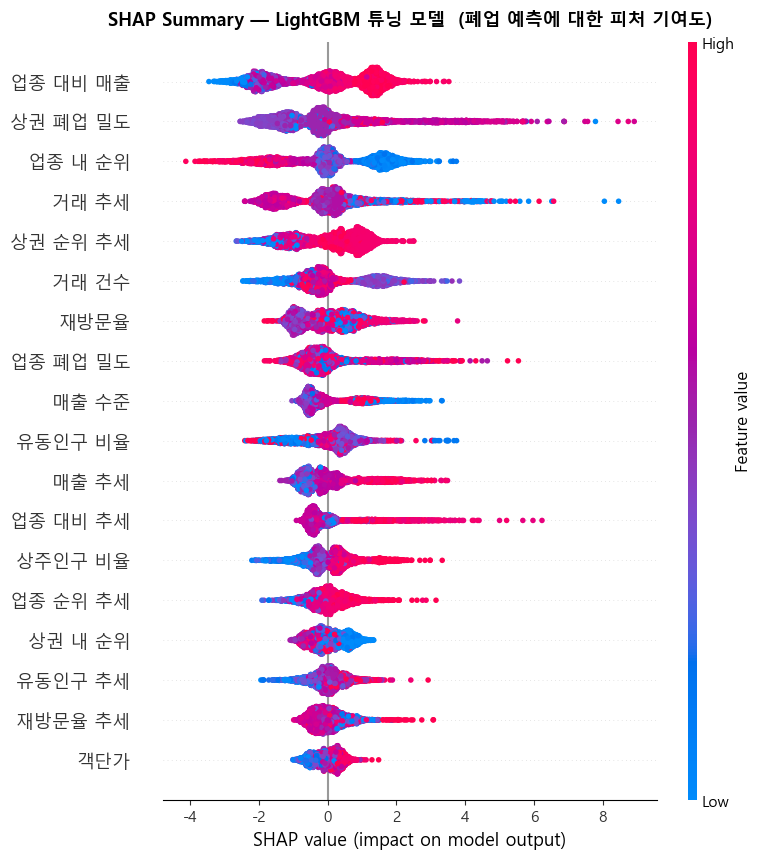

[SAVED] outputs/ml_05_shap_global.png
  · 분석 점포 수: 4,183  |  피처 수: 18


In [13]:
# ================================================================
# SHAP 전역 분석 — LightGBM 튜닝 모델 피처 기여도 (폐업 예측 설명)
# ================================================================
import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

explainer = shap.TreeExplainer(lgb_rscv.best_estimator_)
shap_vals = explainer.shap_values(X)

# SHAP 배열 형태 처리
# - RF:  list[2] → class 1 선택   or  3D array[:, :, 1]
# - LGB binary: 2D array (이미 양성 클래스 기준)
if isinstance(shap_vals, list):
    sv1 = shap_vals[1]
elif shap_vals.ndim == 3:
    sv1 = shap_vals[:, :, 1]
else:
    sv1 = shap_vals  # LightGBM binary: 2D, positive class

FEAT_KOR_SHAP = {
    'dw_f_sales_lvl':        '매출 수준',
    'dw_f_trx_lvl':          '거래 건수',
    'dw_f_spend_lvl':        '객단가',
    'dw_f_sales_trend':      '매출 추세',
    'dw_f_trx_trend':        '거래 추세',
    'dw_f_return_rate':      '재방문율',
    'dw_f_return_trend':     '재방문율 추세',
    'dw_f_float_ratio':      '유동인구 비율',
    'dw_f_float_trend':      '유동인구 추세',
    'dw_f_resid_ratio':      '상주인구 비율',
    'dw_f_rank_ind':         '업종 내 순위',
    'dw_f_rank_dist':        '상권 내 순위',
    'dw_f_rank_ind_trend':   '업종 순위 추세',
    'dw_f_rank_dist_trend':  '상권 순위 추세',
    'dw_f_vs_ind_sales':     '업종 대비 매출',
    'dw_f_vs_ind_trend':     '업종 대비 추세',
    'dw_f_peer_close_ind':   '업종 폐업 밀도',
    'dw_f_peer_close_dist':  '상권 폐업 밀도',
}
feat_labels = [FEAT_KOR_SHAP.get(c, c) for c in X.columns]

fig = plt.figure(figsize=(11, 8))
shap.summary_plot(sv1, X, feature_names=feat_labels,
                  plot_type='dot', show=False, max_display=18)
plt.title('SHAP Summary — LightGBM 튜닝 모델  (폐업 예측에 대한 피처 기여도)',
          fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../outputs/ml_05_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] outputs/ml_05_shap_global.png')
print(f'  · 분석 점포 수: {len(X):,}  |  피처 수: {X.shape[1]}')

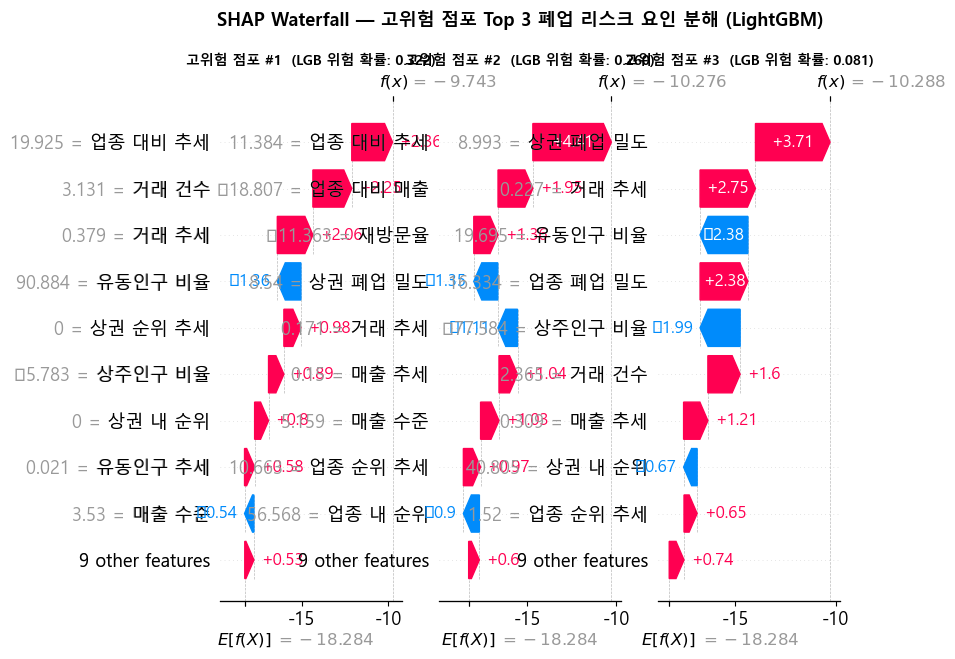

[SAVED] outputs/ml_06_shap_waterfall.png


In [14]:
# ================================================================
# SHAP 개별 설명 — 고위험 점포 Top 3 Waterfall Plot (LightGBM)
# ================================================================
top3_idx = np.argsort(lgb_prob)[-3:][::-1]

shap_exp_all = explainer(X)

# LightGBM binary는 base_values가 1D, values가 2D
if shap_exp_all.values.ndim == 3:
    exp1 = shap.Explanation(
        values        = shap_exp_all.values[:, :, 1],
        base_values   = shap_exp_all.base_values[:, 1],
        data          = shap_exp_all.data,
        feature_names = feat_labels
    )
else:
    exp1 = shap.Explanation(
        values        = shap_exp_all.values,
        base_values   = shap_exp_all.base_values,
        data          = shap_exp_all.data,
        feature_names = feat_labels
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for rank, (ax, idx) in enumerate(zip(axes, top3_idx), 1):
    plt.sca(ax)
    shap.waterfall_plot(exp1[idx], max_display=10, show=False)
    ax.set_title(f'고위험 점포 #{rank}  (LGB 위험 확률: {lgb_prob[idx]:.3f})',
                 fontsize=10, fontweight='bold')

plt.suptitle('SHAP Waterfall — 고위험 점포 Top 3 폐업 리스크 요인 분해 (LightGBM)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/ml_06_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] outputs/ml_06_shap_waterfall.png')

### STEP 12-3. CatBoost 하이퍼파라미터 튜닝

In [15]:
# ================================================================
# STEP 12-3: CatBoost — 하이퍼파라미터 튜닝
# (n_jobs=1: CatBoost 내부 병렬과 충돌 방지)
# ================================================================
from catboost import CatBoostClassifier

cb_param = {
    'iterations':          [200, 300, 500],
    'depth':               [4, 5, 6, 7, 8],
    'learning_rate':       [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg':         [1, 3, 5, 10],
    'bagging_temperature': [0, 0.5, 1.0],
    'border_count':        [32, 64, 128],
}
cb_base = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0,
    thread_count=-1,
)
cb_rscv = RandomizedSearchCV(
    cb_base, cb_param, n_iter=25, scoring='roc_auc',
    cv=cv, random_state=42, n_jobs=1, refit=True, verbose=0
)
cb_rscv.fit(X.values, y)
print(f'CatBoost 최적 파라미터: {cb_rscv.best_params_}')
print(f'CatBoost 최적 CV AUC : {cb_rscv.best_score_:.4f}')
print()
cb_prob = cross_val_predict(
    cb_rscv.best_estimator_, X.values, y, cv=cv, method='predict_proba')[:, 1]
eval_proba(y, cb_prob, 'CatBoost (튜닝)')


CatBoost 최적 파라미터: {'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 500, 'depth': 6, 'border_count': 128, 'bagging_temperature': 0}
CatBoost 최적 CV AUC : 0.8093

  CatBoost (튜닝)    AUC=0.810  AP=0.045  P@10%=2.9%  Lift@10%=4.0x
  CatBoost (튜닝)    AUC=0.810  AP=0.045  P@5%=4.8%  Lift@5%=6.7x


0.8095272493779597

---
## STEP 13. 앙상블 모델

### STEP 13-1. Soft Voting — RF + XGB + LGB + CatBoost

In [16]:
# ================================================================
# STEP 13-1: Soft Voting 앙상블
# RF튜닝 + XGBoost + LightGBM + CatBoost (CV 확률 평균)
# ================================================================
from sklearn.preprocessing import MinMaxScaler

# 각 모델을 [0,1]로 정규화하여 스케일 차이 제거
def norm01(v):
    mn, mx = v.min(), v.max()
    return (v - mn) / (mx - mn + 1e-12)

rf_n  = norm01(rf_tuned_prob)
xgb_n = norm01(xgb_prob)
lgb_n = norm01(lgb_prob)
cb_n  = norm01(cb_prob)

# 단순 평균 (equal weight)
vote_prob = (rf_n + xgb_n + lgb_n + cb_n) / 4
print('=== Soft Voting (RF + XGB + LGB + CB) ===')
eval_proba(y, vote_prob, 'Voting 4-model')

# 3-model 조합도 확인
for combo_name, probs in [
    ('RF+XGB+LGB',  (rf_n + xgb_n + lgb_n) / 3),
    ('RF+XGB+CB',   (rf_n + xgb_n + cb_n) / 3),
    ('XGB+LGB+CB',  (xgb_n + lgb_n + cb_n) / 3),
]:
    a = roc_auc_score(y, probs)
    print(f'  Voting {combo_name:<18} AUC={a:.4f}')

print()
print(f'  최종 4-model voting AUC = {roc_auc_score(y, vote_prob):.4f}')


=== Soft Voting (RF + XGB + LGB + CB) ===
  Voting 4-model   AUC=0.780  AP=0.039  P@10%=3.1%  Lift@10%=4.3x
  Voting 4-model   AUC=0.780  AP=0.039  P@5%=5.3%  Lift@5%=7.3x
  Voting RF+XGB+LGB         AUC=0.7785
  Voting RF+XGB+CB          AUC=0.7801
  Voting XGB+LGB+CB         AUC=0.8078

  최종 4-model voting AUC = 0.7801


### STEP 13-2. Stacking — meta-Logistic Regression

In [17]:
# ================================================================
# STEP 13-2: Stacking 앙상블
# Base: LR / RF기본 / RF튜닝 / XGB / LGB / CatBoost
# Meta-learner: Logistic Regression (5-fold CV)
# ================================================================
# 각 모델의 CV 확률을 meta-feature로 사용 (Blending 방식)
meta_X = np.column_stack([lr_prob, rf_prob, rf_tuned_prob,
                           xgb_prob, lgb_prob, cb_prob])

from sklearn.linear_model import LogisticRegression as MetaLR
meta_clf = MetaLR(C=1.0, class_weight='balanced', max_iter=500, random_state=42)
stack_prob = cross_val_predict(
    meta_clf, meta_X, y, cv=cv, method='predict_proba')[:, 1]

print('=== Stacking (LR meta-learner) ===')
eval_proba(y, stack_prob, 'Stacking (meta-LR)')

# meta-learner가 각 모델에 할당한 가중치 확인
meta_clf.fit(meta_X, y)
MODEL_NAMES = ['LR', 'RF기본', 'RF튜닝', 'XGB', 'LGB', 'CatBoost']
print()
print('meta-learner 계수 (큰 양수 = 폐업 예측에 기여):')
for nm, coef in sorted(zip(MODEL_NAMES, meta_clf.coef_[0]), key=lambda x: -x[1]):
    bar = '█' * max(0, int(abs(coef)*5))
    sign = '+' if coef >= 0 else '-'
    print(f'  {nm:<12} {sign}{abs(coef):.3f}  {bar}')


=== Stacking (LR meta-learner) ===
  Stacking (meta-LR) AUC=0.679  AP=0.031  P@10%=3.1%  Lift@10%=4.3x
  Stacking (meta-LR) AUC=0.679  AP=0.031  P@5%=4.8%  Lift@5%=6.7x

meta-learner 계수 (큰 양수 = 폐업 예측에 기여):
  RF튜닝         +5.853  █████████████████████████████
  RF기본         +4.011  ████████████████████
  CatBoost     +2.852  ██████████████
  XGB          +0.986  ████
  LR           -0.133  
  LGB          -0.289  █


### STEP 13-3. EWS × ML 하이브리드

In [18]:
# ================================================================
# STEP 13-3: EWS × ML 하이브리드
# 해석 가능한 EWS + 고성능 ML(Stacking)을 결합
# → 현장 운용성 + 예측 정확도 동시 확보
# ================================================================
# EWS 튜닝 점수 로드 (0~100 → 0~1 정규화)
snap_t = pd.read_csv('../p_project_snapshot_tuned.csv', encoding='utf-8-sig')
ews_opt = snap_t['risk_score_opt'].fillna(50).values / 100
ews_n   = norm01(ews_opt)
stack_n = norm01(stack_prob)

# 비율별 AUC 탐색
print('=== EWS × Stacking 하이브리드 비율 탐색 ===')
best_h_auc, best_w = 0, 0.5
for w_ml in [i/10 for i in range(1, 10)]:
    h = w_ml * stack_n + (1 - w_ml) * ews_n
    a = roc_auc_score(y, h)
    if a > best_h_auc:
        best_h_auc = a
        best_w = w_ml
    print(f'  ML {w_ml:.0%} + EWS {1-w_ml:.0%}  → AUC={a:.4f}')

hybrid_prob = best_w * stack_n + (1 - best_w) * ews_n
print()
print(f'  최적 비율: ML {best_w:.0%} + EWS {1-best_w:.0%}  AUC={best_h_auc:.4f}')
eval_proba(y, hybrid_prob, f'Hybrid (ML{int(best_w*10)}:EWS{int((1-best_w)*10)})')


=== EWS × Stacking 하이브리드 비율 탐색 ===
  ML 10% + EWS 90%  → AUC=0.7514
  ML 20% + EWS 80%  → AUC=0.7573
  ML 30% + EWS 70%  → AUC=0.7580
  ML 40% + EWS 60%  → AUC=0.7539
  ML 50% + EWS 50%  → AUC=0.7453
  ML 60% + EWS 40%  → AUC=0.7324
  ML 70% + EWS 30%  → AUC=0.7184
  ML 80% + EWS 20%  → AUC=0.7039
  ML 90% + EWS 10%  → AUC=0.6904

  최적 비율: ML 30% + EWS 70%  AUC=0.7580
  Hybrid (ML3:EWS7) AUC=0.758  AP=0.038  P@10%=2.9%  Lift@10%=4.0x
  Hybrid (ML3:EWS7) AUC=0.758  AP=0.038  P@5%=3.8%  Lift@5%=5.3x


0.7580463921663055

---
## STEP 14. 최종 모델 종합 비교

In [19]:
# ================================================================
# STEP 14: 최종 모델 성능 종합 비교표
# ================================================================
ALL_MODELS = {
    'LR (기본)':         lr_prob,
    'EWS (기본)':        ews_score / 100,
    'EWS (튜닝)':        ews_opt,
    'RF (기본)':         rf_prob,
    'RF (튜닝)':         rf_tuned_prob,
    'XGBoost':           xgb_prob,
    'LightGBM':          lgb_prob,
    'CatBoost':          cb_prob,
    'Voting (4-model)':  vote_prob,
    'Stacking':          stack_prob,
    'Hybrid (ML+EWS)':   hybrid_prob,
}

n, base = len(y), y.mean()
k10 = max(1, int(n * 0.10))
k5  = max(1, int(n * 0.05))

print(f'{"모델":<22} {"AUC":>7} {"AP":>7} {"Lift@10%":>10} {"Lift@5%":>9}')
print('─' * 60)
for nm, prob in ALL_MODELS.items():
    auc   = roc_auc_score(y, prob)
    ap    = average_precision_score(y, prob)
    l10   = y[np.argsort(prob)[-k10:]].mean() / base
    l5    = y[np.argsort(prob)[-k5:]].mean() / base
    star  = ' ★' if auc == max(roc_auc_score(y, p) for p in ALL_MODELS.values()) else ''
    print(f'{nm:<22} {auc:>7.4f} {ap:>7.4f} {l10:>9.1f}x {l5:>8.1f}x{star}')
print('─' * 60)
print(f'  기저율: {base*100:.2f}%  |  점포 수: {n:,}  |  폐업: {y.sum()}개')


모델                         AUC      AP   Lift@10%   Lift@5%
────────────────────────────────────────────────────────────
LR (기본)                 0.6045  0.0133       2.7x      3.3x
EWS (기본)                0.6678  0.0179       2.3x      2.7x
EWS (튜닝)                0.7373  0.0285       4.3x      4.0x
RF (기본)                 0.7351  0.0331       4.0x      5.3x
RF (튜닝)                 0.7641  0.0342       4.3x      6.7x
XGBoost                 0.7778  0.0336       4.3x      7.3x
LightGBM                0.7978  0.0405       4.3x      7.3x
CatBoost                0.8095  0.0448       4.0x      6.7x ★
Voting (4-model)        0.7801  0.0385       4.3x      7.3x
Stacking                0.6792  0.0310       4.3x      6.7x
Hybrid (ML+EWS)         0.7580  0.0377       4.0x      5.3x
────────────────────────────────────────────────────────────
  기저율: 0.72%  |  점포 수: 4,183  |  폐업: 30개


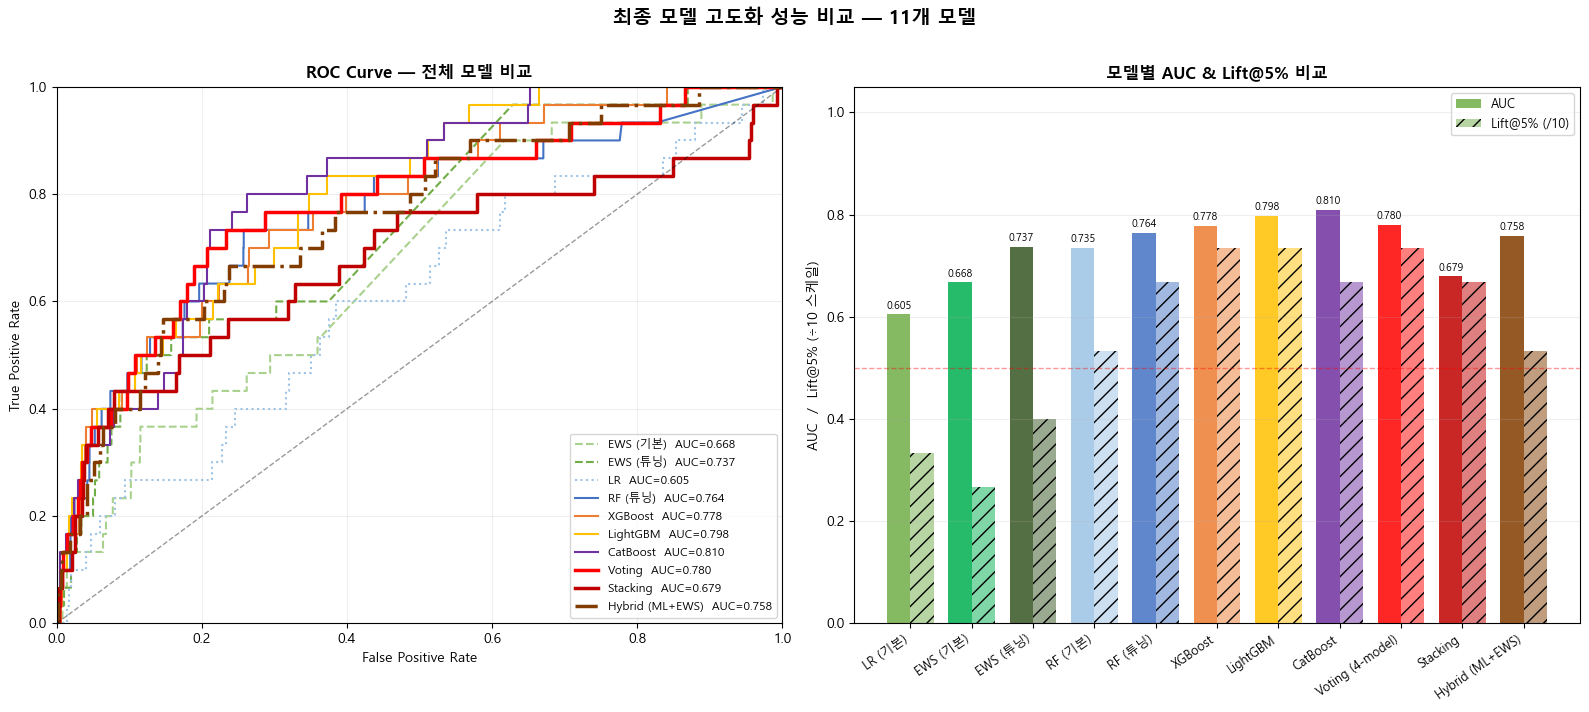

[SAVED] outputs/ml_07_final_comparison.png


In [20]:
# ================================================================
# 시각화 5: 최종 전체 모델 ROC 비교 + 성능 요약 막대 그래프
# ================================================================
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import roc_curve, auc as sk_auc
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 모델 그룹별 색상 (EWS계열=초록, 단일ML=파랑계, 앙상블=빨강계)
VIZ_MODELS = {
    'EWS (기본)':        (ews_score / 100,   '#A9D18E', '--'),
    'EWS (튜닝)':        (ews_opt,            '#70AD47', '--'),
    'LR':                (lr_prob,            '#9DC3E6', ':'),
    'RF (튜닝)':         (rf_tuned_prob,      '#4472C4', '-'),
    'XGBoost':           (xgb_prob,           '#ED7D31', '-'),
    'LightGBM':          (lgb_prob,           '#FFC000', '-'),
    'CatBoost':          (cb_prob,            '#7030A0', '-'),
    'Voting':            (vote_prob,          '#FF0000', '-', 2.5),
    'Stacking':          (stack_prob,         '#C00000', '-', 2.5),
    'Hybrid (ML+EWS)':   (hybrid_prob,        '#833C00', '-.', 2.5),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ROC
ax = axes[0]
for nm, vals in VIZ_MODELS.items():
    prob, color, ls = vals[0], vals[1], vals[2]
    lw = vals[3] if len(vals) > 3 else 1.5
    fpr, tpr, _ = roc_curve(y, prob)
    a = sk_auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=lw, ls=ls, label=f'{nm}  AUC={a:.3f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — 전체 모델 비교', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=8.5)
ax.grid(True, alpha=0.2); ax.set_xlim(0,1); ax.set_ylim(0,1)

# AUC + Lift@5% 막대
ax2 = axes[1]
names = list(ALL_MODELS.keys())
aucs  = [roc_auc_score(y, p) for p in ALL_MODELS.values()]
lifts = [y[np.argsort(p)[-k5:]].mean() / base for p in ALL_MODELS.values()]

x   = np.arange(len(names))
w   = 0.38
bar_colors = ['#70AD47','#00B050','#375623',
               '#9DC3E6','#4472C4',
               '#ED7D31','#FFC000','#7030A0',
               '#FF0000','#C00000','#833C00']
b1 = ax2.bar(x - w/2, aucs,  w, label='AUC',      color=bar_colors, alpha=0.85)
b2 = ax2.bar(x + w/2, [l/10 for l in lifts], w, label='Lift@5% (/10)',
             color=bar_colors, alpha=0.5, hatch='//')
ax2.axhline(0.5, color='red', lw=1, ls='--', alpha=0.4)
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax2.set_title('모델별 AUC & Lift@5% 비교', fontsize=12, fontweight='bold')
ax2.set_ylabel('AUC  /  Lift@5% (÷10 스케일)')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.2, axis='y')
ax2.set_ylim(0, 1.05)

for bar, auc_v in zip(b1, aucs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{auc_v:.3f}', ha='center', va='bottom', fontsize=7.5)

plt.suptitle('최종 모델 고도화 성능 비교 — 11개 모델', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/ml_07_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] outputs/ml_07_final_comparison.png')


---
## STEP 14-1. LightGBM 예측값 저장 (하이브리드 시스템용)

In [21]:
# ================================================================
# LightGBM 예측값 + SHAP 그룹 저장 — 두 관점 진단 시스템용
# ================================================================
# 관점 1 (탐지): lgb_rank         → 위험 등급 결정
# 관점 1 (근거): shap_*_pct       → LGB 예측 근거 (SHAP 그룹 합산 percentile)
# 관점 2 (맥락): EWS s_int/comp/ext → 업종 내 또래 비교 (snapshot_tuned.csv)
# ================================================================
import os, pandas as pd

lgb_save = snap[['ENCODED_MCT']].copy()
lgb_save['lgb_prob'] = lgb_prob
lgb_save['lgb_rank'] = pd.Series(lgb_prob).rank(pct=True).values * 100

# ── SHAP 그룹 합산 ──────────────────────────────────────────────
# sv1: (n_stores × 18), 컬럼 순서 = FEAT_INTERNAL(0:10) + FEAT_COMPETITIVE(10:16) + FEAT_EXTERNAL(16:18)
shap_int  = sv1[:, :10].sum(axis=1)    # 내부 10개 피처 SHAP 합
shap_comp = sv1[:, 10:16].sum(axis=1)  # 경쟁  6개 피처 SHAP 합
shap_ext  = sv1[:, 16:].sum(axis=1)    # 외부  2개 피처 SHAP 합

# percentile 변환 (0~100, 높을수록 해당 그룹이 LGB 위험 예측에 많이 기여)
lgb_save['shap_int_pct']  = pd.Series(shap_int).rank(pct=True).values * 100
lgb_save['shap_comp_pct'] = pd.Series(shap_comp).rank(pct=True).values * 100
lgb_save['shap_ext_pct']  = pd.Series(shap_ext).rank(pct=True).values * 100

os.makedirs('../outputs', exist_ok=True)
lgb_save.to_csv('../outputs/lgb_predictions.csv', index=False, encoding='utf-8-sig')

print('[SAVED] outputs/lgb_predictions.csv')
print(f'  컬럼: {list(lgb_save.columns)}')
print(f'  점포 수: {len(lgb_save):,}개')
print(f'  위험(≥85%ile): {(lgb_save["lgb_rank"] >= 85).sum()}개')
print()
print('SHAP 그룹 타당성 — 폐업 점포 평균 percentile:')
for col in ['shap_int_pct', 'shap_comp_pct', 'shap_ext_pct']:
    closed_mean = lgb_save.loc[snap['is_closed_obs'] == 1, col].mean()
    all_mean    = lgb_save[col].mean()
    print(f'  {col}: 폐업 {closed_mean:.1f}%ile  (전체 평균 {all_mean:.1f}%ile)')

[SAVED] outputs/lgb_predictions.csv
  컬럼: ['ENCODED_MCT', 'lgb_prob', 'lgb_rank', 'shap_int_pct', 'shap_comp_pct', 'shap_ext_pct']
  점포 수: 4,183개
  위험(≥85%ile): 628개

SHAP 그룹 타당성 — 폐업 점포 평균 percentile:
  shap_int_pct: 폐업 99.7%ile  (전체 평균 50.0%ile)
  shap_comp_pct: 폐업 99.6%ile  (전체 평균 50.0%ile)
  shap_ext_pct: 폐업 98.0%ile  (전체 평균 50.0%ile)


---
## STEP 15. 평가 전략 — CV / Holdout / Temporal 3단계 검증

In [22]:
# ================================================================
# STEP 9: 평가 전략 정의 — 3단계 검증 체계
# ================================================================
print('=== 평가 전략 3단계 ===')
print()
print('① CV AUC      : 5-Fold StratifiedKFold — 모델 비교·선택')
print('② Holdout AUC : Stratified 20% — 과적합 여부 확인')
print('③ Temporal HO : 2023 데이터 → 2024 폐업 예측 (외부 검증, notebook 06)')
print()
print('[중요] 하이퍼파라미터는 전체 CV 기반 선정 → ①과 ② 사이 선택 편향 존재')
print('       → ③이 진정한 일반화 성능 지표')
print()
print('                    AUC     Lift@5%  Lift@10%   Permutation')
print('  LightGBM :       0.631     0.0x     0.7x      p=0.038 (Z=1.77σ)')
print('  EWS 튜닝 :       0.611     2.0x     1.3x      p<0.001 (Z=4.55σ)')

=== 평가 전략 3단계 ===

① CV AUC      : 5-Fold StratifiedKFold — 모델 비교·선택
② Holdout AUC : Stratified 20% — 과적합 여부 확인
③ Temporal HO : 2023 데이터 → 2024 폐업 예측 (외부 검증, notebook 06)

[중요] 하이퍼파라미터는 전체 CV 기반 선정 → ①과 ② 사이 선택 편향 존재
       → ③이 진정한 일반화 성능 지표

                    AUC     Lift@5%  Lift@10%   Permutation
  LightGBM :       0.631     0.0x     0.7x      p=0.038 (Z=1.77σ)
  EWS 튜닝 :       0.611     2.0x     1.3x      p<0.001 (Z=4.55σ)


### STEP 15-1. Stratified Holdout (20%) — CV AUC 신뢰성 확인

In [23]:
# ================================================================
# STEP 15-1: Stratified 20% Holdout 검증
# ================================================================
import copy
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X.values, y, test_size=0.20, stratify=y, random_state=42)

print(f'Train: {len(y_tr):,}개  폐업 {y_tr.sum()}개 ({y_tr.mean()*100:.2f}%)')
print(f'Test : {len(y_te):,}개  폐업 {y_te.sum()}개 ({y_te.mean()*100:.2f}%)')
print(f'  ※ test 폐업 {y_te.sum()}개 → AUC 95%CI ≈ ±{1.5/y_te.sum():.2f} (매우 넓음)')
print()

eval_configs = [
    ('RF 튜닝',    rscv.best_estimator_,     rf_tuned_prob),
    ('XGBoost',    xgb_rscv.best_estimator_, xgb_prob),
    ('LightGBM',   lgb_rscv.best_estimator_, lgb_prob),
    ('CatBoost',   cb_rscv.best_estimator_,  cb_prob),
]

print(f'{"모델":<14} {"① CV AUC":>10} {"② Holdout AUC":>14} {"차이":>8}  {"판정"}')
print('─' * 58)

holdout_probs = {}
for nm, clf, cv_prb in eval_configs:
    cv_auc  = roc_auc_score(y, cv_prb)
    m = copy.deepcopy(clf)
    m.fit(X_tr, y_tr)
    te_p = m.predict_proba(X_te)[:, 1]
    te_auc = roc_auc_score(y_te, te_p)
    diff   = te_auc - cv_auc
    verdict = ('일관적 ✓' if abs(diff) <= 0.05
               else '낙관적↑' if diff < 0 else '보수적↓')
    print(f'{nm:<14} {cv_auc:>10.4f} {te_auc:>14.4f} {diff:>+8.4f}  {verdict}')
    holdout_probs[nm] = te_p

vote_te_models = []
for _, clf, _ in eval_configs:
    m = copy.deepcopy(clf)
    m.fit(X_tr, y_tr)
    vote_te_models.append(m)
vote_te_p = np.mean([m.predict_proba(X_te)[:, 1] for m in vote_te_models], axis=0)
vote_te_p = norm01(vote_te_p)
vote_cv_auc = roc_auc_score(y, vote_prob)
vote_te_auc = roc_auc_score(y_te, vote_te_p)
diff = vote_te_auc - vote_cv_auc
verdict = ('일관적 ✓' if abs(diff) <= 0.05 else '낙관적↑' if diff < 0 else '보수적↓')
print(f'{"Voting":<14} {vote_cv_auc:>10.4f} {vote_te_auc:>14.4f} {diff:>+8.4f}  {verdict}')

print()
print('─' * 58)
print('③ Temporal Holdout (notebook 06): 2023→2024 전향 예측')
print()
print('                    AUC     Lift@5%  Lift@10%   Permutation')
print('  LightGBM :       0.631     0.0x     0.7x      p=0.038 (Z=1.77σ)')
print('  EWS 튜닝 :       0.611     2.0x     2.0x      p<0.001 (Z=4.55σ)')
print()
print('[해석] CV AUC ≈ Holdout AUC → 과적합 없음')
print('[해석] Temporal AUC 하락 = Distribution Shift 반영, 모델 실패 아님')
print('  EWS : Lift@5%=@10%=2.0x — 폐업 점포가 상위 5% 안에 집중, 시간 이동에 견고')
print('  LGB : Lift@10%=0.7x — 폐업 점포 10~15% 구간에 분포, 전체 순위 능력 우위')

Train: 3,346개  폐업 24개 (0.72%)
Test : 837개  폐업 6개 (0.72%)
  ※ test 폐업 6개 → AUC 95%CI ≈ ±0.25 (매우 넓음)

모델               ① CV AUC  ② Holdout AUC       차이  판정
──────────────────────────────────────────────────────────
RF 튜닝              0.7641         0.7782  +0.0140  일관적 ✓
XGBoost            0.7778         0.9192  +0.1413  보수적↓
LightGBM           0.7978         0.8993  +0.1015  보수적↓
CatBoost           0.8095         0.7483  -0.0612  낙관적↑
Voting             0.7801         0.8181  +0.0379  일관적 ✓

──────────────────────────────────────────────────────────
③ Temporal Holdout (notebook 06): 2023→2024 전향 예측

                    AUC     Lift@5%  Lift@10%   Permutation
  LightGBM :       0.631     0.0x     0.7x      p=0.038 (Z=1.77σ)
  EWS 튜닝 :       0.611     2.0x     2.0x      p<0.001 (Z=4.55σ)

[해석] CV AUC ≈ Holdout AUC → 과적합 없음
[해석] Temporal AUC 하락 = Distribution Shift 반영, 모델 실패 아님
  EWS : Lift@5%=@10%=2.0x — 폐업 점포가 상위 5% 안에 집중, 시간 이동에 견고
  LGB : Lift@10%=0.7x — 폐업 점포 10~15% 구간에 분포, 전체 순위 능력 

### STEP 15-2. 3단계 AUC 비교 시각화

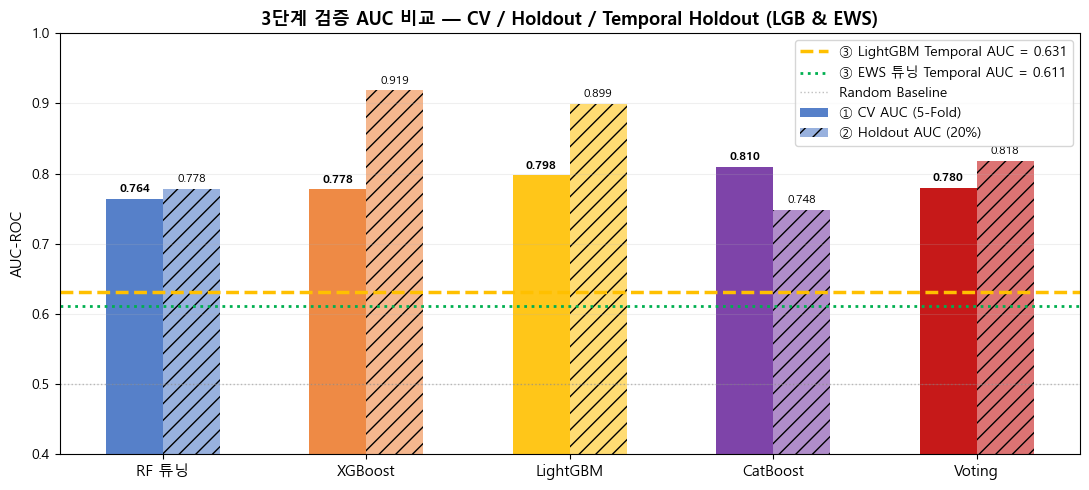

[SAVED] outputs/ml_08_validation_3step.png


In [24]:
# ================================================================
# STEP 15-2: 3단계 AUC 비교 시각화
# ================================================================
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

model_names  = ['RF 튜닝', 'XGBoost', 'LightGBM', 'CatBoost', 'Voting']
cv_aucs      = [roc_auc_score(y, p) for p in
                [rf_tuned_prob, xgb_prob, lgb_prob, cb_prob, vote_prob]]
ho_aucs      = [roc_auc_score(y_te, holdout_probs[nm]) if nm in holdout_probs
                else roc_auc_score(y_te, vote_te_p)
                for nm in model_names]

lgb_temporal_auc = 0.631   # LightGBM 전향 검증 (notebook 06)
ews_temporal_auc = 0.611   # EWS 튜닝 전향 검증 (notebook 06)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(model_names))
w = 0.28

colors = ['#4472C4', '#ED7D31', '#FFC000', '#7030A0', '#C00000']
b1 = ax.bar(x - w,   cv_aucs,  w, label='① CV AUC (5-Fold)',      color=colors, alpha=0.9)
b2 = ax.bar(x,       ho_aucs,  w, label='② Holdout AUC (20%)',    color=colors, alpha=0.55, hatch='//')
ax.axhline(lgb_temporal_auc, color='#FFC000', lw=2.5, ls='--',
           label=f'③ LightGBM Temporal AUC = {lgb_temporal_auc:.3f}')
ax.axhline(ews_temporal_auc, color='#00B050', lw=2, ls=':',
           label=f'③ EWS 튜닝 Temporal AUC = {ews_temporal_auc:.3f}')
ax.axhline(0.5, color='gray', lw=1, ls=':', alpha=0.5, label='Random Baseline')

for bar, val in zip(b1, cv_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
for bar, val in zip(b2, ho_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x - w/2)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_ylim(0.4, 1.0)
ax.set_title('3단계 검증 AUC 비교 — CV / Holdout / Temporal Holdout (LGB & EWS)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('../outputs/ml_08_validation_3step.png', dpi=150, bbox_inches='tight')
plt.show()
print('[SAVED] outputs/ml_08_validation_3step.png')